<h2><b>Part 1 : Function</b></h2>

In [1]:
print("L")

L


In [11]:
def addie(x , y):
    print(f"{x} & {y} are being added")

In [12]:
addie(3,6)

3 & 6 are being added


In [3]:
def add2(x, y):
    print(f"{x} & {y} are being added")
    pass

In [10]:
add2(30,20)

30 & 20 are being added


<h2><b>Part 2 : MatplotLib</b></h2>

In [37]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline                         

In [12]:
x = np.linspace(0, 10, 500)
y = np.cumsum(np.random.randn(500, 6), 0)

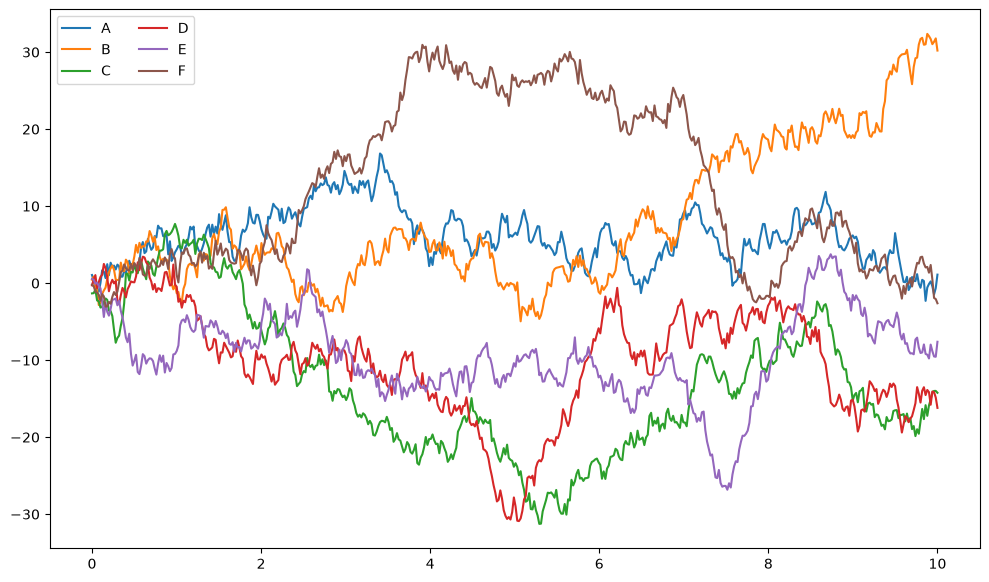

In [13]:
plt.figure(figsize=(12, 7))
plt.plot(x, y)
plt.legend('ABCDEF', ncol=2, loc='upper left')

<h2><b>Part 2 : API request</b></h2>

In [15]:
import requests
import pandas as pd

requesting data from API kraken

In [17]:
def get_historic_price(symbol, after='2018-09-01'):
    
    url = 'https://api.kraken.com/0/public/OHLC'
    pair = f"{symbol.upper()}USD" # XBTUSD when symbol='xbt' for example
    
    resp = requests.get(url, params={
        "pair": pair,
        'interval': 60,
        'since': str(int(pd.Timestamp(after).timestamp()))
    })
    resp.raise_for_status()
    
    data = resp.json()
    
    results_key = [k for k in data['result'].keys() if k != 'last'][0]
    results = [
        (close_time, float(open), float(high), float(low), float(close), float(volume))
        for (close_time, open, high, low, close, vwap, volume, count)
        in data['result'][results_key]
    ]
    df = pd.DataFrame(results, columns=[
        'CloseTime', 'OpenPrice', 'HighPrice', 'LowPrice', 'ClosePrice', 'Volume'
    ])
    df['CloseTime'] = pd.to_datetime(df['CloseTime'], unit='s')
    df.set_index('CloseTime', inplace=True)
    return df

This function fetches historical hourly OHLC (Open, High, Low, Close) price data for a specified cryptocurrency from the Kraken public API, processes the response, and formats it into a clean, time-indexed pandas DataFrame ready for analysis.

Function Parameters

symbol: The ticker string for the cryptocurrency asset (e.g., 'xbt' or 'eth'), which is converted to uppercase and combined with USD to form Kraken's trading pair format (e.g., XBTUSD).

after: A string representing the starting date (defaulting to '2018-09-01') from which to pull historical data.

API Request Mechanics

It sends an HTTP GET request to Kraken's public endpoint ([https://api.kraken.com/0/public/OHLC](https://api.kraken.com/0/public/OHLC)).

It sets the interval to 60, which requests 1-hour candlestick data.

It converts the after date string into a Unix timestamp using pd.Timestamp(after).timestamp() and passes it to the since parameter so Kraken only returns data forward from that date.

resp.raise_for_status() ensures the script halts and throws an error if the API request fails (e.g., a 404 or 500 error).

Data Parsing and Cleansing

resp.json() parses the incoming JSON payload.

A list comprehension isolates the correct data array by finding the key in data['result'] that isn't the 'last' pagination marker.

It unpacks Kraken's raw 8-item candle arrays—keeping only the close time, open, high, low, close, and volume, while casting them all to floats. VWAP and trade count are intentionally dropped.

DataFrame Formatting

It builds a pandas DataFrame assigning descriptive column names: CloseTime, OpenPrice, HighPrice, LowPrice, ClosePrice, and Volume.

It transforms the Unix epoch integer in CloseTime into a readable UTC datetime object using pd.to_datetime(..., unit='s').

It sets CloseTime as the DataFrame index, making it ideal for time-series operations, filtering, and plotting inside Jupyter.

In [18]:
last_week = (pd.Timestamp.now() - pd.offsets.Day(7))
last_week

Timestamp('2026-08-23 14:18:08.398560')

In [20]:
btc = get_historic_price('btc', after=last_week)

In [21]:
eth = get_historic_price('eth', after=last_week)

Bitcoin

In [23]:
btc.head()

,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume
CloseTime,,,,,
2026-08-23 15:00:00,77184.0,77319.5,76900.7,77138.4,71.892000
2026-08-23 16:00:00,77138.4,77438.0,77138.4,77424.2,41.754484
2026-08-23 17:00:00,77424.3,77435.7,77161.4,77185.9,35.881411
2026-08-23 18:00:00,77185.9,77392.8,77124.0,77312.0,17.524517
2026-08-23 19:00:00,77328.1,77447.2,77249.1,77333.0,68.607755


In [24]:
btc.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 162 entries, 2026-08-23 15:00:00 to 2026-08-30 08:00:00
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   OpenPrice   162 non-null    float64
 1   HighPrice   162 non-null    float64
 2   LowPrice    162 non-null    float64
 3   ClosePrice  162 non-null    float64
 4   Volume      162 non-null    float64
dtypes: float64(5)
memory usage: 7.6 KB


<h2><b>Part 3 : Graphing</b></h2>

<Axes: xlabel='CloseTime'>

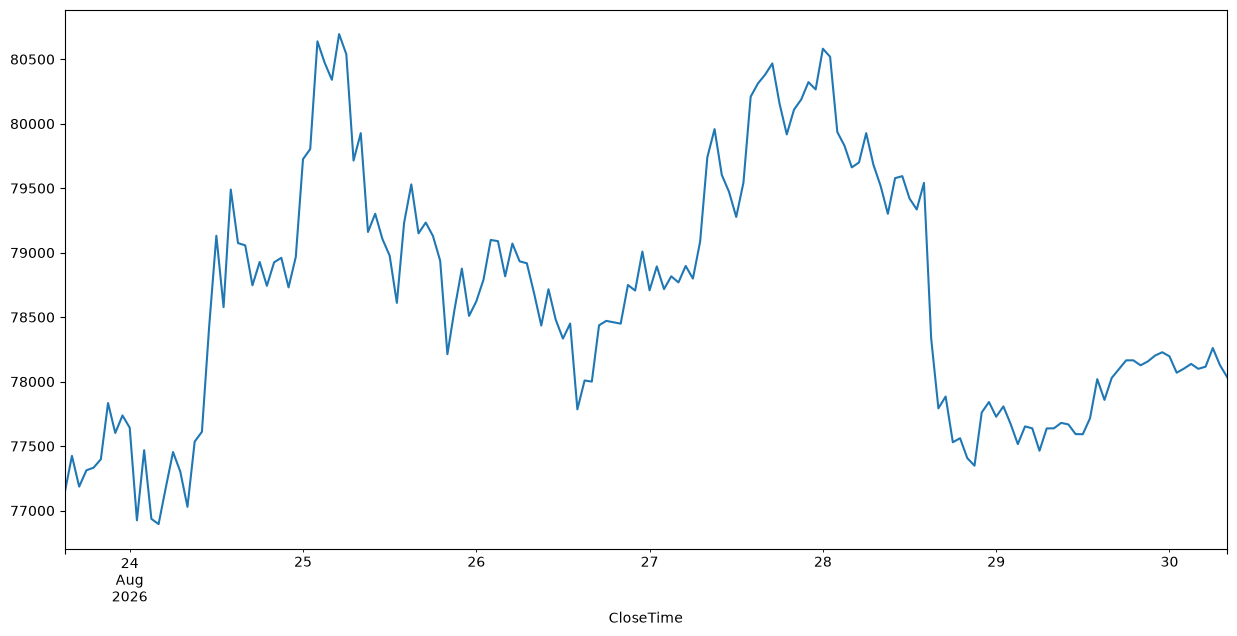

In [25]:
btc['ClosePrice'].plot(figsize=(15, 7))

Ether

In [26]:
btc.head()

,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume
CloseTime,,,,,
2026-08-23 15:00:00,77184.0,77319.5,76900.7,77138.4,71.892000
2026-08-23 16:00:00,77138.4,77438.0,77138.4,77424.2,41.754484
2026-08-23 17:00:00,77424.3,77435.7,77161.4,77185.9,35.881411
2026-08-23 18:00:00,77185.9,77392.8,77124.0,77312.0,17.524517
2026-08-23 19:00:00,77328.1,77447.2,77249.1,77333.0,68.607755


In [27]:
eth.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 162 entries, 2026-08-23 15:00:00 to 2026-08-30 08:00:00
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   OpenPrice   162 non-null    float64
 1   HighPrice   162 non-null    float64
 2   LowPrice    162 non-null    float64
 3   ClosePrice  162 non-null    float64
 4   Volume      162 non-null    float64
dtypes: float64(5)
memory usage: 7.6 KB


<Axes: xlabel='CloseTime'>

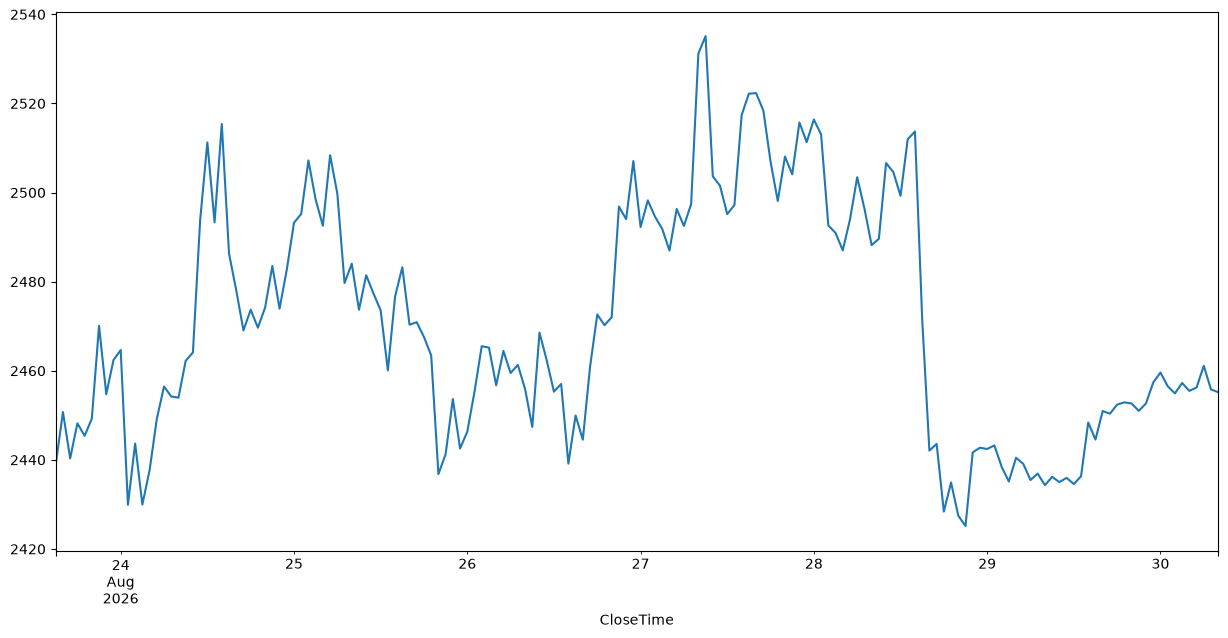

In [28]:
eth['ClosePrice'].plot(figsize=(15, 7))

Bonus: Dynamic plots with Bokeh

In [29]:
from bokeh.plotting import figure, output_file, show
from bokeh.io import output_notebook

In [30]:
output_notebook()

Loading BokehJS ...

In [34]:
p1 = figure(x_axis_type="datetime", title="Crypto Prices", width=800)
p1.grid.grid_line_alpha=0.3
p1.xaxis.axis_label = 'Date'
p1.yaxis.axis_label = 'Price'

p1.line(btc.index, btc['ClosePrice'], color='#f2a900', legend_label='Bitcoin')
#p1.line(eth.index, eth['ClosePrice'], color='#A6CEE3', legend_label='Ether')

p1.legend.location = "top_left"

show(p1)

p1 = figure(x_axis_type="datetime", title="Crypto Prices", width=800): Initializes a new Bokeh plot canvas. It sets the X-axis to natively handle time-series data (like pandas DatetimeIndex), gives the plot the title "Crypto Prices", and sets the canvas width to 800 pixels.

p1.grid.grid_line_alpha = 0.3: Adjusts the opacity (alpha transparency) of the background grid lines to 0.3, making them subtle rather than distracting.

p1.xaxis.axis_label = 'Date' & p1.yaxis.axis_label = 'Price': Assigns text labels to the horizontal and vertical axes.

p1.line(btc.index, btc['ClosePrice'], color='#f2a900', legend_label='Bitcoin'): Draws a line chart on the plot. It uses the btc DataFrame index (timestamps) for the X-axis and the ClosePrice column for the Y-axis. It colors the line Bitcoin gold (#f2a900) and adds a label for the legend.

#p1.line(eth.index, eth['ClosePrice'], color='#A6CEE3', legend_label='Ether'): A commented-out line of code that would plot Ethereum prices in light blue if uncommented.

p1.legend.location = "top_left": Moves the interactive legend box to the top-left corner of the chart.

show(p1): Renders and displays the completed interactive chart inside your Jupyter Lab environment.

<h2><b>Part 4: Exporting to Excel</b></h2>

We'll now write both our Bitcoin and Ether data as separate sheets:

In [58]:
writer = pd.ExcelWriter('cryptos.xlsx')

In [59]:
btc.to_excel(writer, sheet_name='Bitcoin')

In [60]:
eth.to_excel(writer, sheet_name='Ether')

In [61]:
# Automatically saves and closes the file when exiting the 'with' block
with pd.ExcelWriter("cryptos.xlsx", engine="openpyxl") as writer:
    btc.to_excel(writer, sheet_name="Bitcoin")

In [62]:
df = pd.read_excel("cryptos.xlsx", sheet_name="Bitcoin")
df.head()

,CloseTime,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume
0,2026-08-23 15:00:00,77184.0,77319.5,76900.7,77138.4,71.892000
1,2026-08-23 16:00:00,77138.4,77438.0,77138.4,77424.2,41.754484
2,2026-08-23 17:00:00,77424.3,77435.7,77161.4,77185.9,35.881411
3,2026-08-23 18:00:00,77185.9,77392.8,77124.0,77312.0,17.524517
4,2026-08-23 19:00:00,77328.1,77447.2,77249.1,77333.0,68.607755
